# 关于k8s的基础概念，这个直接看alexey老师的文档即可
https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/10-kubernetes/05-kubernetes-intro.md

看1个老师画的图吧：
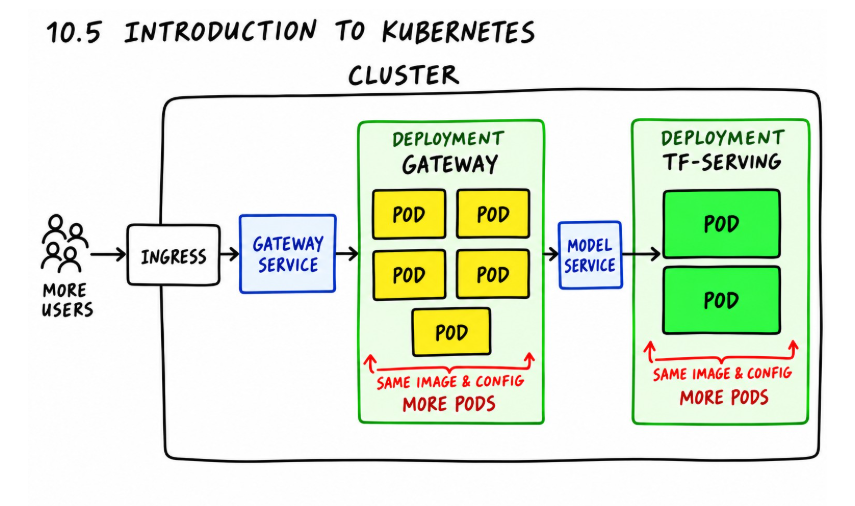

# 一、本地部署K8S
在本课中，我们搭建一个本地的Kubernetes集群，并部署了 简单的网页应用。我们创建一个小型Flask“ping”服务， 构建其映像，创建部署和 Kubernetes 中的服务， 设置了MetalLB，这样我们就能从机器上访问服务。

# kind
- kind 是 “Kubernetes IN Docker” 的缩写。它是一个用来在本地快速创建和运行 Kubernetes 集群的工具，专门用于测试和本地开发。
- kind 的思路很直接：它把 Docker 容器当作 Kubernetes 的“节点”来用
- 我们用kind来创建集群，用kubectl（命令行） 用于与 Kubernetes 交互的工具，以便与之协作。

In [ ]:
# 安装 kind 
curl -Lo ./kind https://kind.sigs.k8s.io/dl/v0.23.0/kind-linux-amd64
chmod +x ./kind
sudo mv ./kind /usr/local/bin/kind

In [ ]:
# kubectl：操作 K8s 的命令行工具
# 安装 kubectl
curl -LO "https://dl.k8s.io/release/$(curl -L -s https://dl.k8s.io/release/stable.txt)/bin/linux/amd64/kubectl"
chmod +x ./kubectl
sudo mv ./kubectl /usr/local/bin/kubectl


In [ ]:
# 装完验证一下：
kind version 和 kubectl version --client 能输出版本号就行。

# 二、拉起一个完整的单节点 K8s 集群
- kind create cluster --name mlops

- 过程如下图：
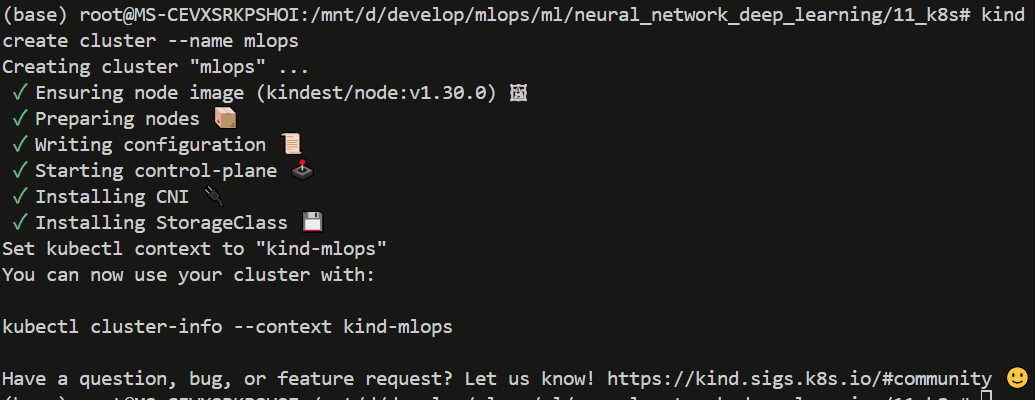

## 此时，可以通过  docker images  和  docker ps -a查看
## 会看到 这样的镜像：kindest/node@sha256:047357ac0cfea04663786a612ba1eaba9702bef25227a794b52890dd8bcd692e047357ac0cfe       1.41GB          416MB    U
## 会看到  这样的容器：就是这个镜像对应的容器
CONTAINER ID   IMAGE                  COMMAND                  CREATED       STATUS       PORTS                       NAMES
1aafb38eec39   kindest/node:v1.30.0   "/usr/local/bin/entr…"   5 hours ago   Up 5 hours   127.0.0.1:35581->6443/tcp   mlops-control-plane
                                        


In [ ]:
# 查看指定 K8s 集群的连接信息（API Server 地址、DNS 等），
# 用来确认 kubectl 当前连的是哪个集群、集群是否可达。
kubectl cluster-info --context kind-mlops

#  检查运行中的服务，确保它正常运行
kubectl get service

# 三. 在ml目录中，创建1个新的目录，用于本节课程的学习
新的目录：/mnt/d/develop/mlops/ml/kind_for_k8s_sample
## 1. 创建一个脚本：ping.py


In [ ]:
from flask import Flask

app = Flask('ping')

@app.route('/ping', methods=['GET'])
def ping():
    return "PONG"

if __name__ == "__main__":
    app.run(debug=True, host='0.0.0.0', port=9696)

In [ ]:
# 在kind_for_k8s_sample 目录中，创建虚拟环境,安装依赖
uv init 
uv venv 
uv add flask gunicorn 


# 创建1个dockerfile文件

In [ ]:
FROM python:3.11.16-slim-bookworm

COPY --from=ghcr.io/astral-sh/uv:latest /uv /uvx /bin/

WORKDIR /app

COPY ["pyproject.toml", "uv.lock", "./"]

# uv sync 会自己创建 .venv 并严格按锁文件安装，--no-dev 表示不带开发依赖
RUN uv sync --locked --no-dev --no-install-project

COPY "ping.py" .

EXPOSE 9696

# 用 uv run 执行，它会自动找到项目里的 .venv
ENTRYPOINT ["uv", "run", "--no-sync", "gunicorn", "--bind=0.0.0.0:9696", "ping:app"]

In [ ]:
# 构建镜像，这种镜像必须要有自定义的tag标签，不能用默认latest标签
docker build -t ping:v001 .

In [ ]:
# 编写 K8s 的 Deployment 配置文件

In [ ]:
apiVersion: apps/v1        # 固定写法，Deployment 用这个 API 版本
kind: Deployment           # 资源类型：Deployment（管理 Pod 的控制器）

metadata:
  name: ping-deployment    # 这个 Deployment 的名字

spec:
  replicas: 1              # 跑 1 个 Pod 副本

  selector:
    matchLabels:
      app: ping            # 它管理所有带 app=ping 标签的 Pod

  template:                # Pod 模板：下面定义每个 Pod 长什么样
    metadata:
      labels:
        app: ping          # 给 Pod 打上 app=ping 标签（要和上面 selector 对上）
    spec:
      containers:
      - name: ping-pod     # 容器名字
        image: ping:v001   # 用哪个镜像
        resources:
          limits:
            memory: "128Mi"  # 最多用 128MB 内存
            cpu: "500m"      # 最多用 0.5 核 CPU  # 1000m==1 核
        ports:
        - containerPort: 9696  # 容器内监听的端口

In [ ]:
# 现在可以将这些应用，应用到我们的Kubernetes集群中 
# 执行如下命令：
kubectl apply -f deployment.yaml
- 执行结果：
deployment.apps/ping-deployment created

In [ ]:
#  将 Docker 镜像加载到集群
kind load docker-image ping:v001 --name mlops
- 执行结果：
(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kind_for_k8s_sample# kind load docker-image ping:v001 --name mlops
Image: "ping:v001" with ID "sha256:fdc44b3bc8bc815ae4bab64d260caca71a46dfea7245c62a81d6459f38dbb634" not yet present on node "mlops-control-plane", loading...

# 查看pod状态    kubectl get pods
(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kind_for_k8s_sample# kubectl get pods
NAME                               READY   STATUS    RESTARTS   AGE
ping-deployment-7bfd99c878-72n85   1/1     Running   0          7m54s

In [ ]:
# 把本机的 9696 端口，转发到 Pod 的 9696 端口。
# 这样你就能用 curl localhost:9696/ping 访问 Pod 里的服务。
- kubectl port-forward ping-deployment-7bfd99c878-72n85 9696:9696
- 命令输出如下：
Forwarding from 127.0.0.1:9696 -> 9696
Forwarding from [::1]:9696 -> 9696

In [ ]:
# 另开终端，测试一下restful api
(base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kind_for_k8s_sample# curl localhost:9696/ping
PONG(base)
- 结果显示，成功了
- port-forward 是临时调试手段，只在本机生效，重启就没了。
- Service 才是持久、可被集群内外访问的正式方式。

# 四、我们不再将端口转发到单个 Pod，而是在部署前，创建一个Service。
- 我们创建：service.yaml 
- 代码如下

In [ ]:
apiVersion: v1            # Service 用 v1 这个 API 版本，固定写法
kind: Service             # 资源类型：Service

metadata:
  name: ping              # Service 的名字，集群内可以通过这个名字访问它

spec:
  type: LoadBalancer      # Service 类型：对外暴露，云环境会分配外部 IP
  selector:               # 选择器：决定这个 Service 把流量转发给哪些 Pod
    app: ping             # 匹配所有带 app=ping 标签的 Pod

  ports:
  - port: 80              # Service 自己监听的端口（集群内/外访问 Service 用的端口）
    targetPort: 9696      # 转发到 Pod 的哪个端口（对应容器的 containerPort）

In [ ]:
# 执行以下命令
kubectl apply -f service.yaml
- 输出：
service/ping created

In [ ]:
# 执行命令   kubectl get service

(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kind_for_k8s_sample# kubectl get service
NAME         TYPE           CLUSTER-IP      EXTERNAL-IP   PORT(S)        AGE
kubernetes   ClusterIP      10.96.0.1       <none>        443/TCP        6h19m
ping         LoadBalancer   10.96.207.199   <pending>     80:32376/TCP   55s

### ping Service 是 LoadBalancer 类型，但 EXTERNAL-IP 显示 pending ——本地 kind 集群没有负载均衡器实现，拿不到外部 IP。
### 所以现在没法直接用外部 IP 访问。
### 把本机 8080 端口转发到 Service ping 的 80 端口，让你能用 curl localhost:8080/ping 测试服务。
### 执行下列命令：
kubectl port-forward service/ping 8080:80

### 测试
curl localhost:8080/ping 
- 输出：PONG

### 数据流向
curl localhost:8080/ping
  → 本机 8080
  → kubectl port-forward
  → Service ping:80
  → Pod:9696
  → Flask 返回 PONG

# 五、 让EXTERNAL-IP在MetalLB中工作
- 如果你想让服务的外部 IP 真正 在 Kind 上工作，Kind 文档里有一个“负载均衡器”页面， 描述该怎么做。
- 安装 MetalLB，一个负载均衡器实现 为集群中的服务分配外部IP地址。

In [ ]:
# 从 GitHub 拉取 MetalLB 的官方 YAML 清单，并直接应用到 K8s 集群里。
# 安装 MetalLB 系统本身，

In [ ]:
kubectl apply -f https://raw.githubusercontent.com/metallb/metallb/v0.13.7/config/manifests/metallb-native.yaml

In [ ]:
# 命令执行的输出：
namespace/metallb-system created
customresourcedefinition.apiextensions.k8s.io/addresspools.metallb.io created
customresourcedefinition.apiextensions.k8s.io/bfdprofiles.metallb.io created
customresourcedefinition.apiextensions.k8s.io/bgpadvertisements.metallb.io created
customresourcedefinition.apiextensions.k8s.io/bgppeers.metallb.io created
customresourcedefinition.apiextensions.k8s.io/communities.metallb.io created
customresourcedefinition.apiextensions.k8s.io/ipaddresspools.metallb.io created
customresourcedefinition.apiextensions.k8s.io/l2advertisements.metallb.io created
serviceaccount/controller created
serviceaccount/speaker created
role.rbac.authorization.k8s.io/controller created
role.rbac.authorization.k8s.io/pod-lister created
clusterrole.rbac.authorization.k8s.io/metallb-system:controller created
clusterrole.rbac.authorization.k8s.io/metallb-system:speaker created
rolebinding.rbac.authorization.k8s.io/controller created
rolebinding.rbac.authorization.k8s.io/pod-lister created
clusterrolebinding.rbac.authorization.k8s.io/metallb-system:controller created
clusterrolebinding.rbac.authorization.k8s.io/metallb-system:speaker created
secret/webhook-server-cert created
service/webhook-service created
deployment.apps/controller created
daemonset.apps/speaker created
validatingwebhookconfiguration.admissionregistration.k8s.io/metallb-webhook-configuration created

- 命名空间	metallb-system
- CRD	addresspools、ipaddresspools、l2advertisements 等（MetalLB 的自定义资源）
- RBAC	ServiceAccount、Role、ClusterRole、Binding（权限）
- 工作负载	controller（Deployment）、speaker（DaemonSet）
- Webhook	证书 Secret + Service + ValidatingWebhook

In [ ]:
# 等 MetalLB 的 Pod 全部进入 Ready 状态，最多等 90 秒。
# 这条命令就是卡住，直到 MetalLB 准备好，确保后续操作能顺利进行。
#它是一个“同步点”：确保 MetalLB 完全就绪后，再继续下一步。
kubectl wait --namespace metallb-system \
  --for=condition=ready pod \
  --selector=app=metallb \
  --timeout=90s

In [ ]:
# 查 kind 网络的 IP 段
# kind 是 kind 专用的 Docker 网络，所有 kind 集群共享它。MetalLB 的 IP 池必须从这个网络的 IP 段里选，否则外部 IP 无法路由。
docker network ls
#输出：
NETWORK ID     NAME      DRIVER    SCOPE
caaafbb46238   bridge    bridge    local
d7b7693faf63   host      host      local
e2a3b0ffc89a   kind      bridge    local
c78a59f07757   none      null      local
#########################################
docker network inspect -f '{{.IPAM.Config}}' kind
#输出：
[{fc00:f853:ccd:e793::/64 invalid Prefix fc00:f853:ccd:e793::1 map[]} {172.18.0.0/16 invalid Prefix 172.18.0.1 map[]}]

In [ ]:
# 创建：metallb-config.yaml    配置代码如下
# 义了两样东西：IP 地址池和 L2 广播方式。

In [ ]:
apiVersion: metallb.io/v1beta1       # MetalLB 的 API 版本
kind: IPAddressPool                  # 资源类型：IP 地址池，给kind网络配置
metadata:
  name: zhf_k8s_metallb              # 这个池子的名字
  namespace: metallb-system
spec:
  addresses:
  - 172.18.255.200-172.18.255.250
---
apiVersion: metallb.io/v1beta1
kind: L2Advertisement               # 资源类型：二层广播
metadata:
  name: empty
  namespace: metallb-system

In [ ]:
# 再次应用部署和服务，更新才能继续，最后应用metallb-config.yaml 配置
kubectl apply -f deployment.yaml
kubectl delete -f service.yaml
kubectl apply -f service.yaml
kubectl apply -f metallb-config.yaml

In [ ]:
# 再次查看service的装填
kubectl get service

NAME         TYPE           CLUSTER-IP     EXTERNAL-IP      PORT(S)        AGE
kubernetes   ClusterIP      10.96.0.1      <none>           443/TCP        19h
ping         LoadBalancer   10.96.126.38   172.18.255.200   80:30182/TCP   3m55s

In [ ]:
# 测试 ，返回 PONG 即表示成功了，在终端中测试
curl 172.18.255.200:80/ping

# 六、向Kubernetes部署TensorFlow模型
### 部署两个服务——TF-Serving模型和 Flask 网关——连接到我们用 kind 创建的本地 Kubernetes 集群。
### 对于 每个服务我们都创建一个部署（pods）和一个服务service（指向pods） 。
### 为了保持整洁，我们将 Kubernetes 配置文件放在一个单独的文件夹中。
- 新的目录：本部分内容，无特殊说明，均在kube_config目录下进行
- mkdir kube_config
/mnt/d/develop/mlops/ml/kube_config

## 1.部署TF-Serving模型
- 首先，我们为TF-Serving模型创建部署，创建 model-deployment.yaml 
- 镜像资源，来自docker compose课程中，给tf serving 做了的新的镜像
- 代码如下：

In [ ]:
apiVersion: apps/v1
kind: Deployment
metadata:
  name: tf_serving_clothing_model
spec:
  replicas: 1
  selector:
    matchLabels:
      app: tf_serving_clothing_model
  template:
    metadata:
      labels:
        app: tf_serving_clothing_model
    spec:
      containers:
      - name: tf_serving_clothing_model
        image: clothing-serving:v1
        resources:
          limits:
            memory: "512Mi"
            cpu: "0.5"
        ports:
        - containerPort: 8500

In [ ]:
# 加载镜像
kind load docker-image clothing-serving:v1 --name mlops

In [ ]:
# 加载配置
kubectl apply -f model-deployment.yaml
# 输出：deployment.apps/tf-serving-clothing-model created

In [ ]:
#方便测试，直接配置端口转发，把本地（WSL2）的 8500 端口，临时转发到集群里那个 Pod 的 8500 端口，可以从外面直接访问这个 Pod 里的服务。
#其中，pod-id 通过kubectl get pods命令查询
kubectl port-forward tf-serving-clothing-model-664f9db47d-95snr 8500:8500

In [ ]:
# 用之前的脚本，直接连接tf  serving测试
(neural_network_deep_learning) (quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/neural_network_deep_learning# python tf_serving_connect.py 
2026-09-21 20:13:27.752651: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
2026-09-21 20:13:38.843984: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
{'dress': -2.1015233993530273, 'hat': -5.5352373123168945, 'longsleeve': -2.531212329864502, 'outwear': -1.957198977470398, 
'pants': 9.972639083862305, 'shirt': -1.3964393138885498, 'shoes': -2.5511271953582764, 'shorts': -0.28122517466545105, 
'skirt': -3.9467363357543945, 't-shirt': -3.624239206314087}

In [ ]:
# 可以看到，得到了正确的输出，说明k8s集群中，tf serving的容器已经在正常工作了。
# 有个小插曲，这个脚本：tf_serving_connect.py 已经无法正常在原来的目录：(neural_network_deep_learning) (quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/neural_network_deep_learning/11_k8s
# 中，运行了，因为上节课最后做的gateway，是去掉本地tensorflow依赖后，在目录创建了，tensoflow自建的库，导致报错。所以我把脚本拷贝出来，到上一层目录中执行。

##  2. 创建模型服务

In [ ]:
# 创建  model-service.yaml
# 代码如下：

In [ ]:
apiVersion: v1
kind: Service
metadata:
  name: tf-serving-clothing-model
spec:
  type: ClusterIP # default service type is always ClusterIP (i.e., internal service)
  selector:
    app: tf-serving-clothing-model
  ports:
  - port: 8500
    targetPort: 8500

In [ ]:
# 创建模型服务
kubectl apply -f model-service.yaml
#输出：service/tf-serving-clothing-model created
# 方便测试，直接配置端口转发，
kubectl port-forward tf-serving-clothing-model-664f9db47d-95snr 8500:8500

In [ ]:
# 测试
(neural_network_deep_learning) (quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/neural_network_deep_learning# python tf_serving_connect.py 
2026-09-21 21:15:08.998986: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
2026-09-21 21:15:19.597096: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
{'dress': -2.1015233993530273, 'hat': -5.5352373123168945, 'longsleeve': -2.531212329864502, 'outwear': -1.957198977470398, 'pants': 9.972639083862305, 'shirt': -1.3964393138885498, 'shoes': -2.5511271953582764, 'shorts': -0.28122517466545105, 'skirt': -3.9467363357543945, 't-shirt': -3.624239206314087}

In [ ]:
# 验证pod和service已经绑定了
(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kube_config# kubectl get pods -o wide
NAME                                         READY   STATUS    RESTARTS   AGE     IP           NODE                  NOMINATED NODE   READINESS GATES
tf-serving-clothing-model-664f9db47d-95snr   1/1     Running   0          3h54m   10.244.0.7   mlops-control-plane   <none>           <none>
(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kube_config# kubectl get endpoints tf-serving-clothing-model
NAME                        ENDPOINTS         AGE
tf-serving-clothing-model   10.244.0.7:8500   48m

##  3. 部署网关

In [ ]:
# 创建 gateway-deployment.yaml 文件
# 代码如下：

In [ ]:
apiVersion: apps/v1              # Deployment 的 API 版本，固定写法
kind: Deployment                 # 资源类型

metadata:
  name: gateway                  # Deployment 名字

spec:
  selector:
    matchLabels:
      app: gateway               # 管理带 app=gateway 标签的 Pod

  template:                      # Pod 模板
    metadata:
      labels:
        app: gateway             # 给 Pod 打标签，要和上面 selector 一致

    spec:
      containers:
      - name: gateway            # 容器名
        image: clothing_gateway:v1_k8s   # 你的 Gateway 镜像
        
        resources:
          requests:
            memory: "512Mi"      # 最少 512MB 内存
            cpu: "100m"          # 最少 0.1 核 CPU
          limits: 
            memory: "1024Mi"      # 最多 128MB 内存
            cpu: "300m"          # 最多 0.1 核 CPU

        ports:
        - containerPort: 9696    # 容器监听 9696

        env:                     # 环境变量
          - name: TF_SERVING_HOST
            value: tf-serving-clothing-model.default.svc.cluster.local:8500 # 代码用这个地址去发起 gRPC 调用

In [ ]:
# 加载镜像，并创建网关部署
kind load docker-image  clothing_gateway:v1_k8s  --name mlops

输出如下：

(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kube_config# kind load docker-image  clothing_gateway:v1_k8s  --name mlops
Image: "clothing_gateway:v1_k8s" with ID "sha256:c4e3d319c9a360f80c7c74c199a243e1356ec07bd0fd1d2fe827eabfd868e3e4" not yet present on node "mlops-control-plane", loading...


In [ ]:
kubectl apply -f gateway-deployment.yaml

输出如下：
(kind_for_k8s_sample) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/kube_config# kubectl apply -f gateway-deployment.yaml
deployment.apps/gateway created

In [ ]:
# 执行下面给命令，本机 127.0.0.1:9696  ──►  Pod 的 9696
kubectl port-forward gateway-6bfd775f8-csmk4 9696:9696

In [ ]:
# 测试--结果正常，测试通过
(neural_network_deep_learning) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/neural_network_deep_learning/11_k8s# python test_gateway.py
状态码: 200
Content-Type: application/json
响应体:
{"dress":-2.1015233993530273,"hat":-5.5352373123168945,"longsleeve":-2.531212329864502,"outwear":-1.957198977470398,"pants":9.972639083862305,"shirt":-1.3964393138885498,"shoes":-2.5511271953582764,"shorts":-0.28122517466545105,"skirt":-3.9467363357543945,"t-shirt":-3.624239206314087}

In [ ]:
# 登录到pod
kubectl exec -it gateway-6bfd775f8-csmk4 -- bash

## 4. 为网关创建服务

In [ ]:
# 创建gateway-service.yaml，代码如下：
apiVersion: v1
kind: Service
metadata:
  name: gateway
spec:
  type: LoadBalancer # External service to communicate with client (i.e., LoadBalancer)
  selector:
    app: gateway
  ports:
  - port: 80 # port of the service
    targetPort: 9696 # port of load balancer

In [ ]:
# 创建网关的服务
kubectl apply -f gateway-service.yaml
# 
kubectl port-forward service/gateway 8080:80
# 测试
# 注意修改测试脚本的这一行：url = 'http://127.0.0.1:8080/predict' 端口要改成8080
# 测试成功
(neural_network_deep_learning) (base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/neural_network_deep_learning/11_k8s# python test_gateway.py
状态码: 200
Content-Type: application/json
响应体:
{"dress":-2.1015233993530273,"hat":-5.5352373123168945,"longsleeve":-2.531212329864502,"outwear":-1.957198977470398,"pants":9.972639083862305,"shirt":-1.3964393138885498,"shoes":-2.5511271953582764,"shorts":-0.28122517466545105,"skirt":-3.9467363357543945,"t-shirt":-3.624239206314087}

# 七、部署至EKS
